# sea ice

## UNDER CONSTRUCTION

Each row is a day from 1980-01-01 to 2019-12-31. Columns are:
- `date` that day in YYYY-MM-DD format
- `extent` a measure of global sea ice

## project idea

I used OLS (Ordinary Least Squares) regression to fit a straight line to the `extent` data. Replace my OLS method with [ridge] regression. Does it make a big difference?

[ridge]: https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression-and-classification

In [1]:
from datetime import timedelta
from sklearn import linear_model
import seaborn as sns
import pandas as pd

In [2]:
# Seaborn comes with some example datasets.
# They are already pandas.DataFrame objects.
# We don't need to load any files.
seaice = sns.load_dataset('seaice')
print(f"{len(seaice)} rows loaded")

# Normalize column names.
seaice.columns = [x.lower().strip() for x in seaice.columns]

# Use date as the index column.
seaice = seaice.set_index('date')

seaice

13175 rows loaded


,extent
date,
1980-01-01,14.200
1980-01-03,14.302
1980-01-05,14.414
1980-01-07,14.518
1980-01-09,14.594
...,...
2019-12-27,12.721
2019-12-28,12.712
2019-12-29,12.780


In [3]:
# Check data types
seaice.dtypes

extent    float64
dtype: object

In [4]:
# Count null markers
seaice.isnull().sum()

extent    0
dtype: int64

<Axes: title={'center': 'sea ice extent'}, xlabel='date', ylabel='extent'>

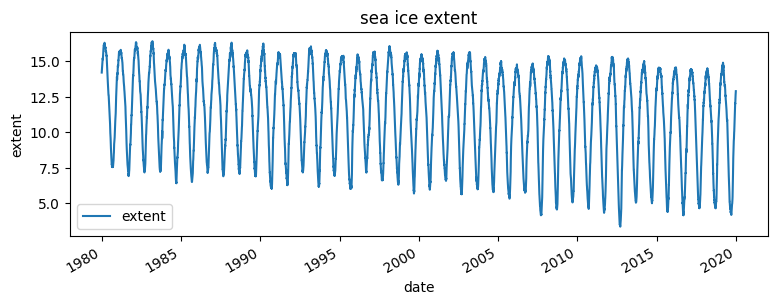

In [5]:
# Plot sea ice extent over time.
plotkw = {
    "title": "sea ice extent",
    "ylabel": "extent",
    "figsize": (9,3),
}
seaice.plot.line(**plotkw)

In [ ]:
# scikit-learn requires some weird tricks.

# The x-axis must be numbers, not timestamps.
# For each row, count days since the first date.
# seaice['days'] = (seaice.index - seaice.index.min())
# seaice['days'] /= timedelta(days=1)
# seaice['days'] = seaice['days'].astype(int)


#days = days.reshape(-1, 1)

seaice

In [12]:
reg = linear_model.LinearRegression()
reg.fit(
    seaice.index.values.astype(int).reshape(-1,1),
    seaice['extent']
)

print(f"The slope is {reg.coef_}")
print(f"The y-intercept is {reg.intercept_}")
reg


The slope is [-1.94716957e-15]
The y-intercept is 13.240288247180032


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<Axes: title={'center': 'sea ice extent'}, ylabel='extent'>

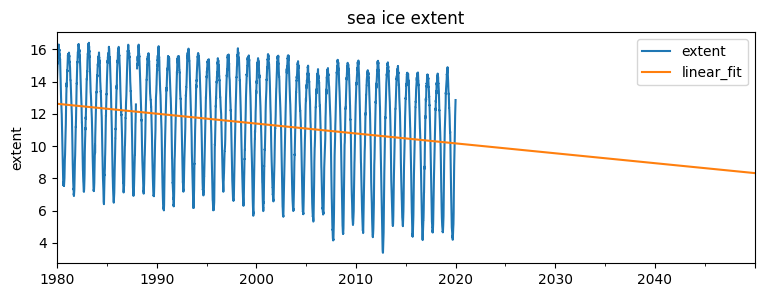

In [22]:
seaice = seaice.reindex(pd.date_range('1980-01-01', '2049-12-31', freq='2D'))
seaice['linear_fit'] = reg.predict(seaice.index.values.astype(int).reshape(-1, 1))
seaice.plot(**plotkw)